In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy
mart  = pd.read_excel('supermarket_sales.xlsx')
shop = pd.read_excel('mart_train_sample.xlsx')
mart.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Mandalay,Member,Female,Food_and_beverages,54.84,3,8.226,172.746,2/20/2019,13:27:00,Credit card,164.52,4.761905,8.226,5.9
1,351-62-0822,B,Mandalay,Member,Female,Fashion_accessories,14.48,4,2.896,60.816,2019-06-02 00:00:00,18:07:00,Ewallet,57.92,4.761905,2.896,4.5
2,529-56-3974,B,Mandalay,Member,Male,Electronic_accessories,25.51,4,5.102,107.142,2019-09-03 00:00:00,17:03:00,Cash,102.04,4.761905,5.102,6.8
3,299-46-1805,B,Mandalay,Member,Female,Sports_and_travel,93.72,6,28.116,590.436,1/15/2019,16:19:00,Cash,562.32,4.761905,28.116,4.5
4,319-50-3348,B,Mandalay,Normal,Female,Home_and_lifestyle,40.30,2,4.030,84.630,2019-11-03 00:00:00,15:30:00,Ewallet,80.60,4.761905,4.030,4.4


In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
crash_df = sns.load_dataset('car_crashes')
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


<Axes: xlabel='not_distracted', ylabel='Count'>

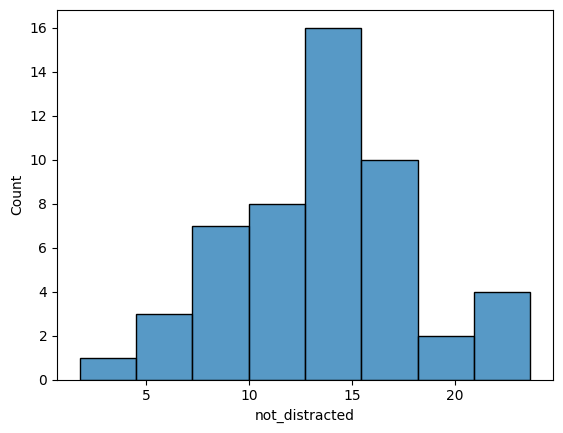

In [9]:
sns.histplot(crash_df['not_distracted'])

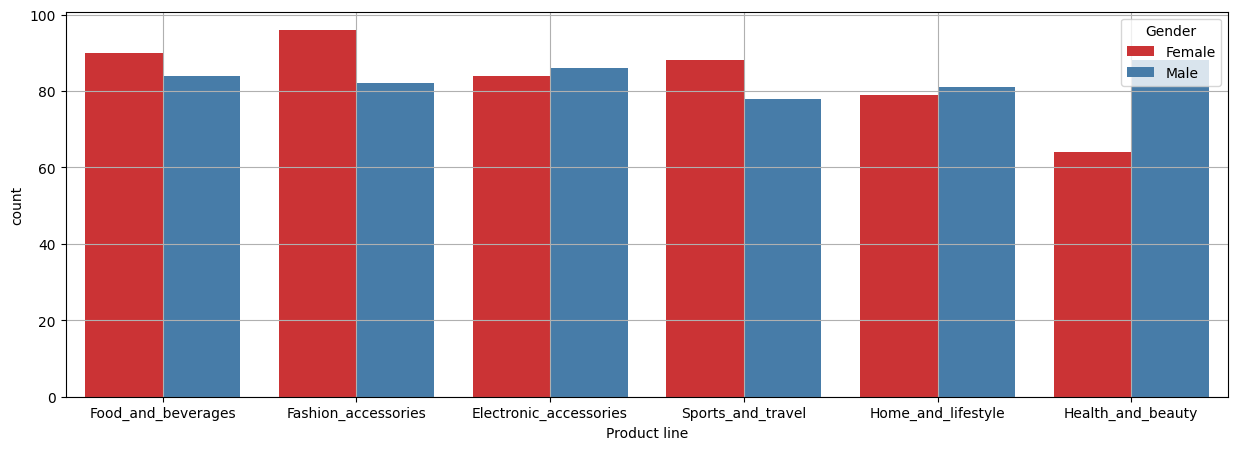

In [18]:
plt.figure(figsize=(15,5))
sns.countplot(x= 'Product line',hue = 'Gender', data= mart, palette = 'Set1')
plt.grid(True)

<Axes: xlabel='count', ylabel='Product line'>

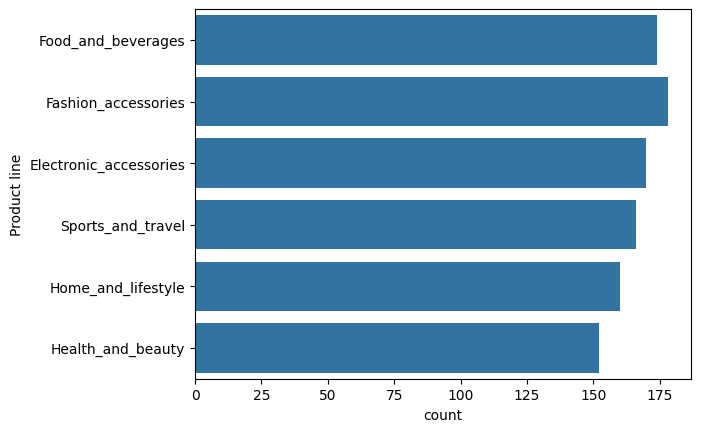

In [12]:
sns.countplot(y= 'Product line', data= mart)

<Axes: xlabel='Product line', ylabel='count'>

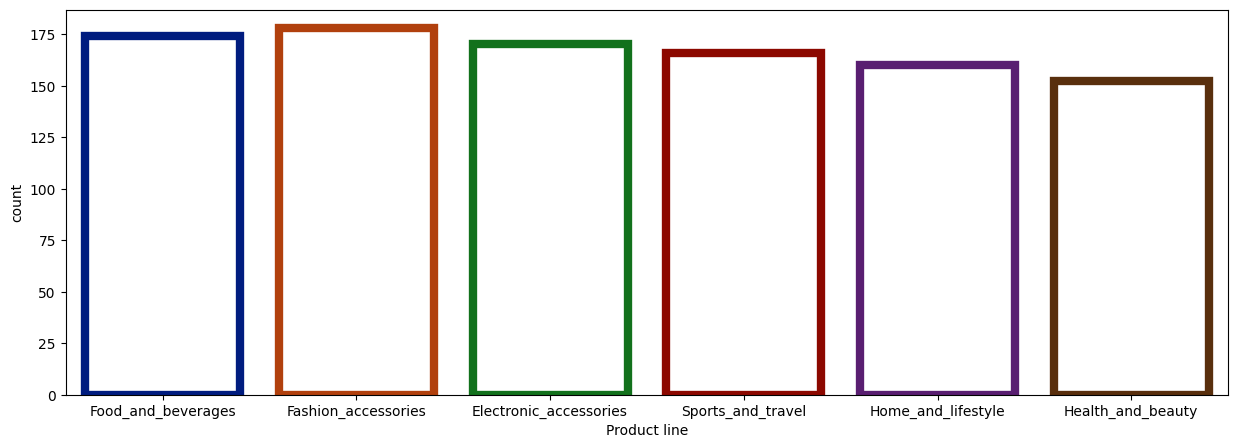

In [34]:
plt.figure(figsize=(15,5))
sns.countplot(x= 'Product line', data= mart, facecolor = (0,0,0,0), edgecolor = sns.color_palette('dark') , linewidth = 6)

<Axes: xlabel='Product line', ylabel='Quantity'>

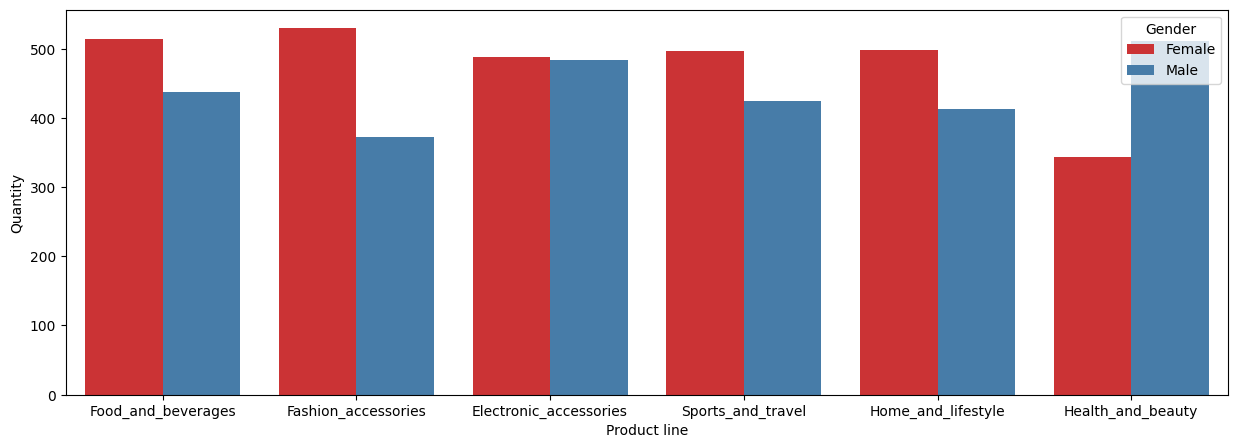

In [13]:
plt.figure(figsize=(15,5))
sns.barplot(x= 'Product line', y = 'Quantity',hue = 'Gender', data= mart, errorbar = None, palette = 'Set1', estimator= sum)

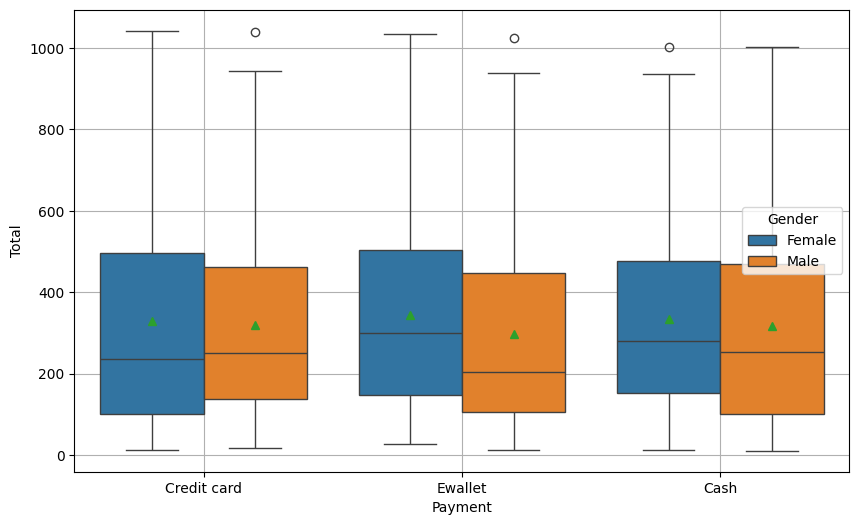

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(y= 'Total',x= 'Payment', data= mart, hue = 'Gender', showmeans = True)
plt.grid(True)

In [32]:
mart['Total'].describe()

count    1000.000000
mean      322.966749
std       245.885335
min        10.678500
25%       124.422375
50%       253.848000
75%       471.350250
max      1042.650000
Name: Total, dtype: float64

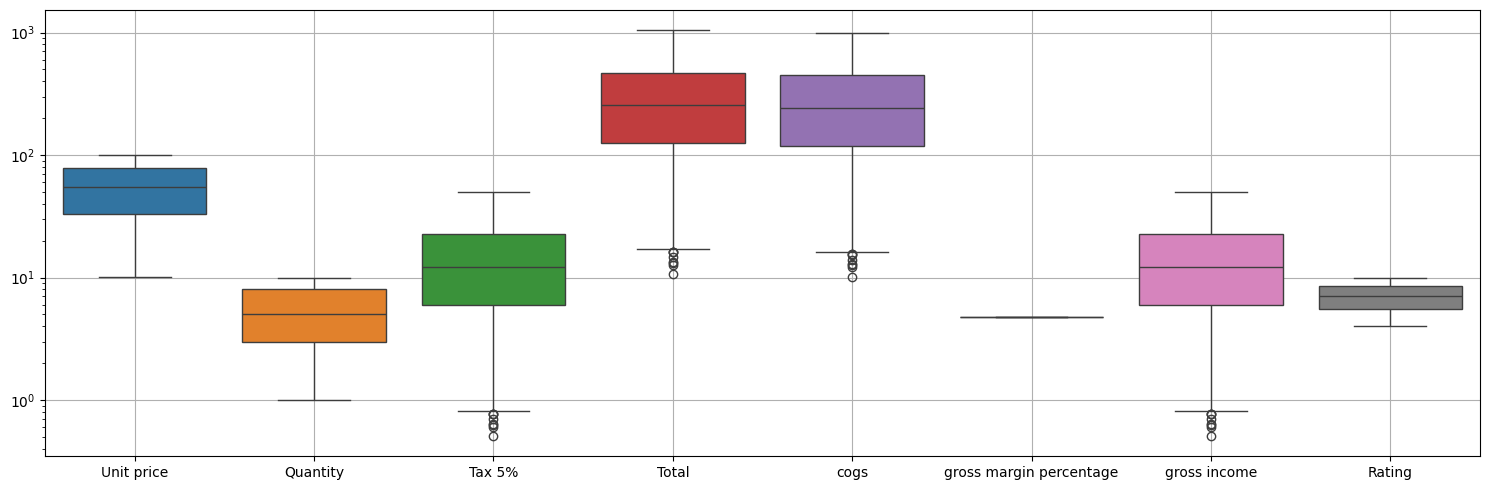

In [33]:
plt.figure(figsize=(15,5))
sns.boxplot(data=mart, log_scale=True)
plt.grid(True)
plt.tight_layout()

<Axes: xlabel='Payment', ylabel='Total'>

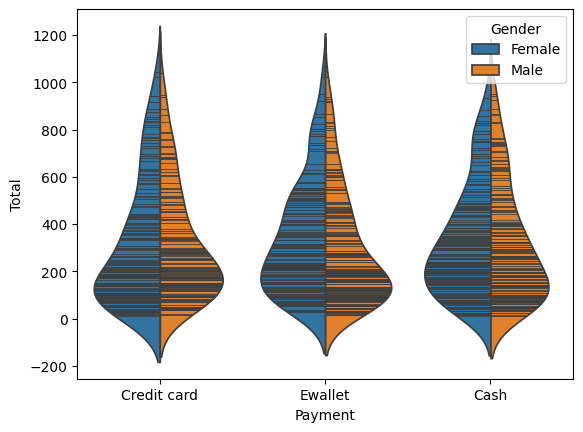

In [5]:
sns.violinplot(y = 'Total', x= 'Payment', hue = 'Gender', split=True, data= mart, inner = 'stick')

<Axes: xlabel='Payment', ylabel='Total'>

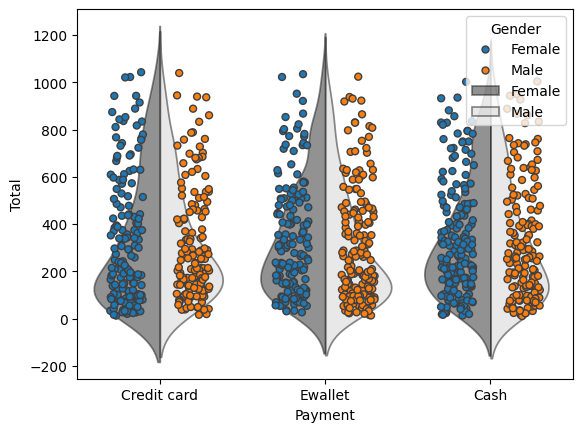

In [14]:
sns.stripplot(y = 'Total', x= 'Payment', hue = 'Gender', data= mart, jitter = 0.2, dodge= True, linewidth= 1)
sns.violinplot(y = 'Total', x= 'Payment', hue = 'Gender', split=True, data= mart, palette='dark:lightgray', inner = None, alpha=0.5)

<Axes: xlabel='Payment', ylabel='Total'>

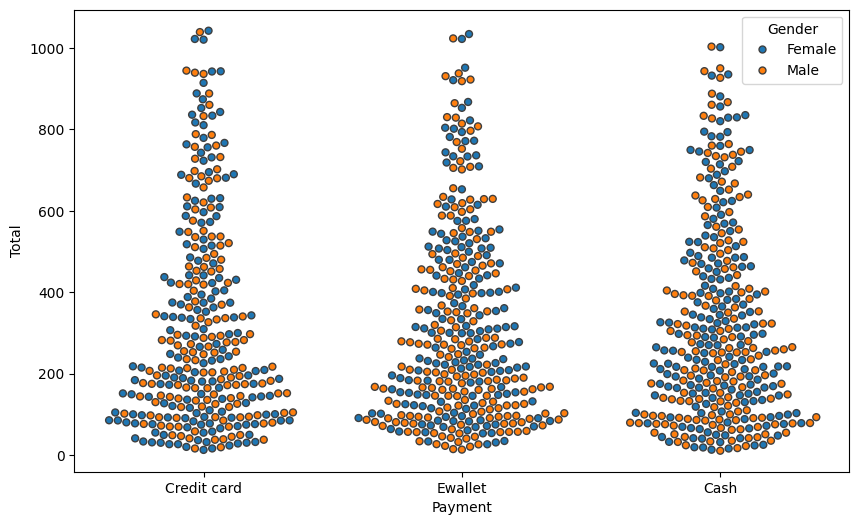

In [5]:
plt.figure(figsize=(10,6))
sns.swarmplot(y = 'Total', x= 'Payment', hue = 'Gender', data= mart,linewidth= 1)

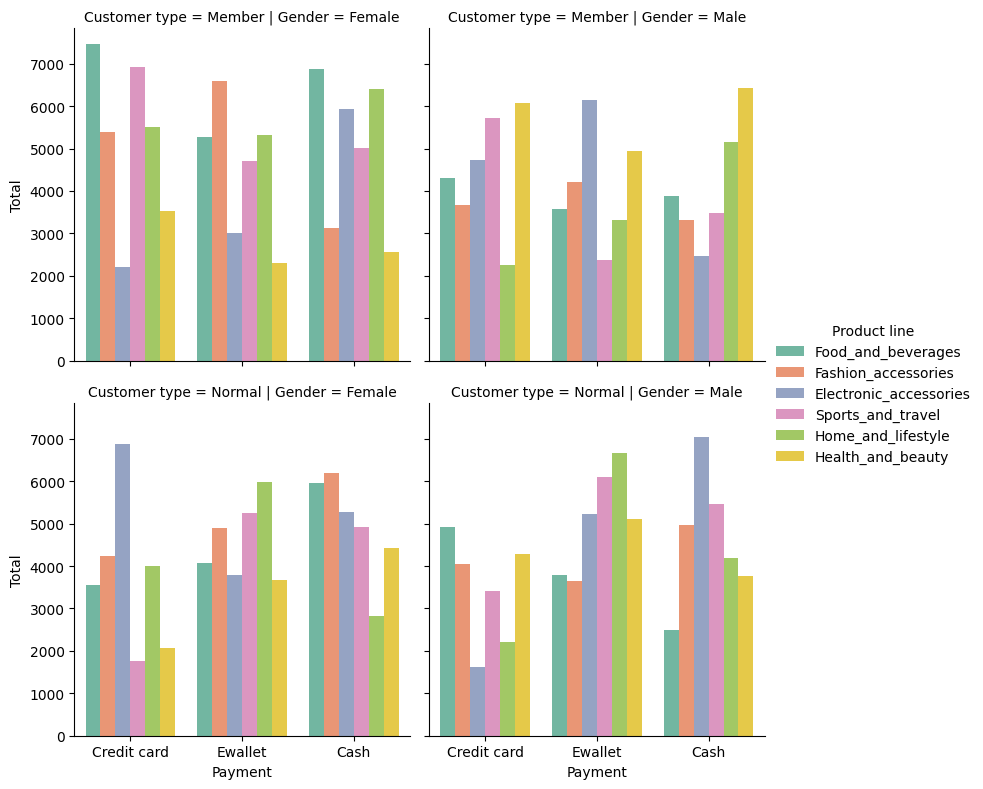

In [14]:
sns.catplot(
    y='Total',
    x='Payment',
    hue='Product line',           # Add this line
    col='Gender',
    row='Customer type',
    data=mart,
    kind='bar',
    height=4,
    aspect=1,
    errorbar=None,
    palette='Set2',
    estimator=np.sum,
)

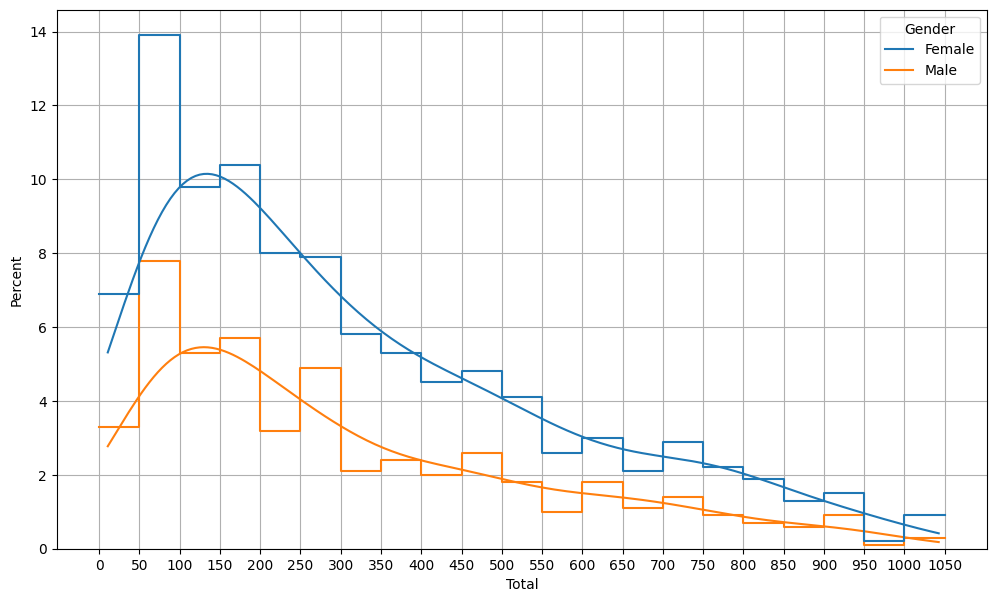

In [4]:
plt.figure(figsize=(12,7))
sns.histplot(x= 'Total',data= mart,hue= 'Gender',multiple= 'stack', bins= np.arange(0,1100,50), stat= 'percent', element= 'step', fill= False, kde= True)
plt.xticks(np.arange(0,1100,50))
plt.grid(True)


<Axes: xlabel='Total', ylabel='Density'>

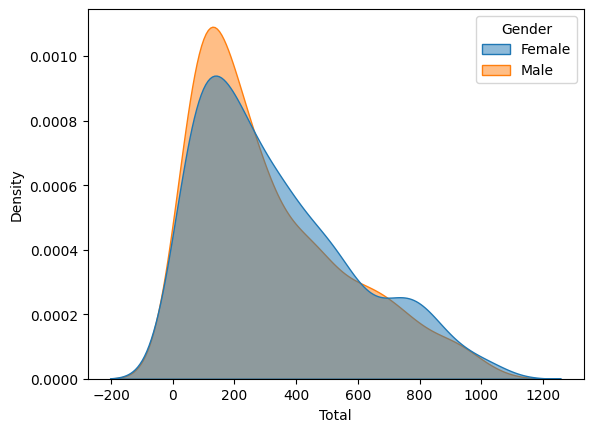

In [11]:
sns.kdeplot(x= 'Total',data= mart, hue= 'Gender', fill= True, alpha= 0.5)

<Axes: xlabel='Unit price', ylabel='gross income'>

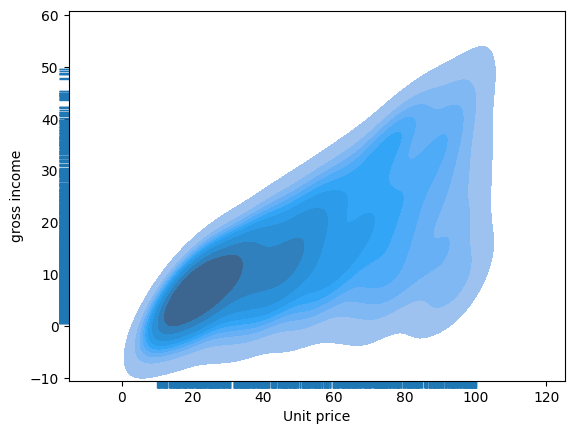

In [30]:
sns.kdeplot(x= 'Unit price',data= mart, y= 'gross income', fill= True)
sns.rugplot(x= 'Unit price',data= mart, y= 'gross income', height= -0.02, clip_on= False)

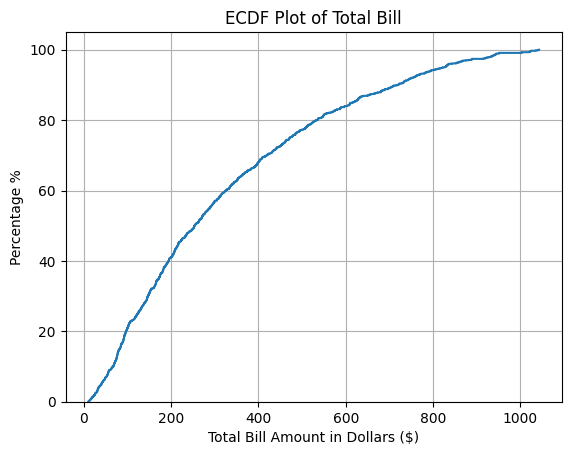

In [3]:
sns.ecdfplot(data= mart, x= 'Total', stat= 'percent')
plt.title('ECDF Plot of Total Bill')
plt.ylabel('Percentage %')
plt.xlabel('Total Bill Amount in Dollars ($)')
plt.grid(True)

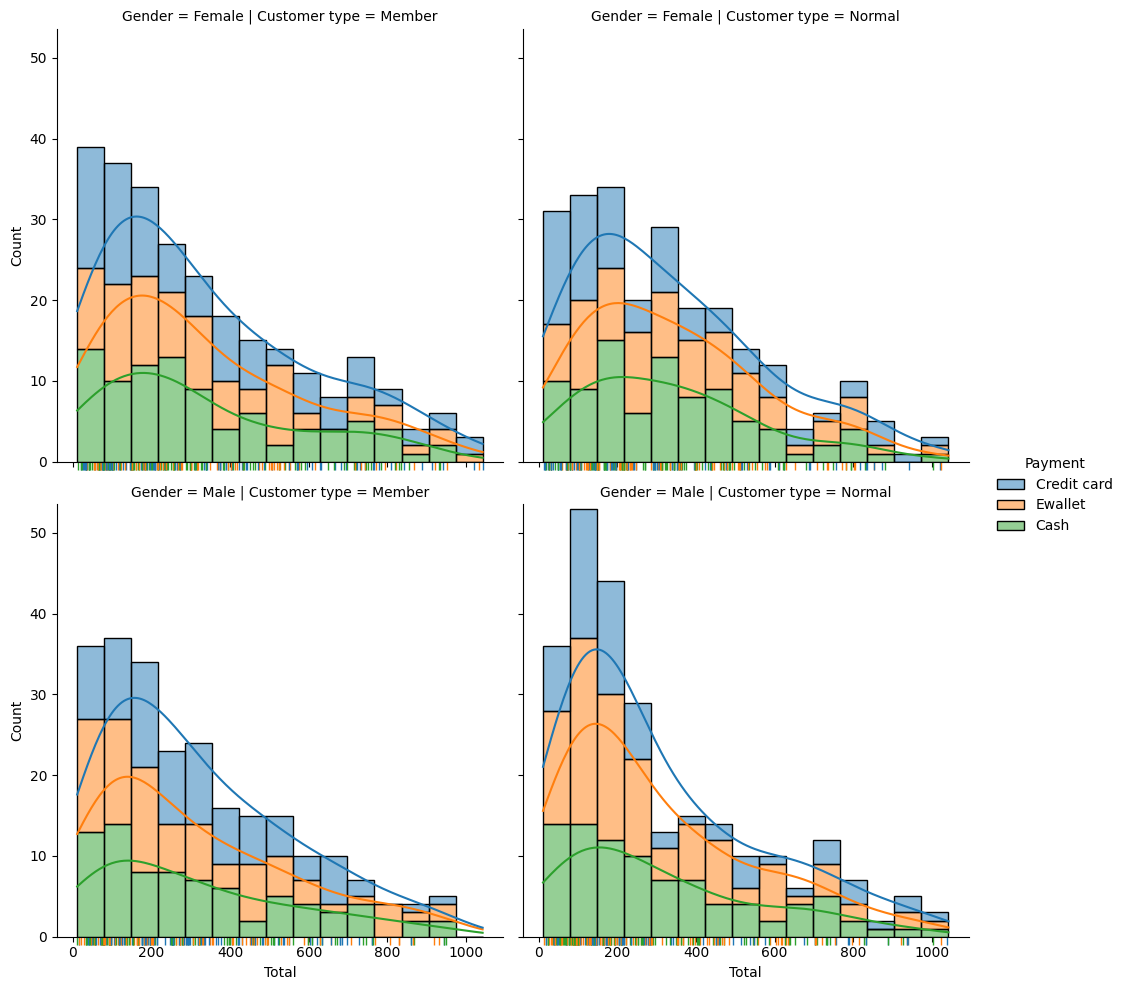

In [13]:
sns.displot(data= mart, x= 'Total', kde= True, rug= True, rug_kws= {'height': -0.02, 'clip_on': False}, row= 'Gender', col= 'Customer type', hue= 'Payment',multiple= 'stack' )

In [2]:
iris= sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


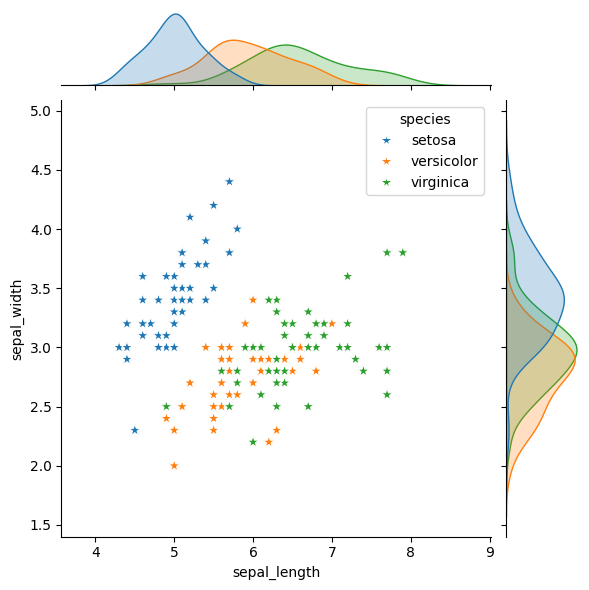

In [22]:
sns.jointplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue='species',
    joint_kws=dict(marker='*', s=80)
)

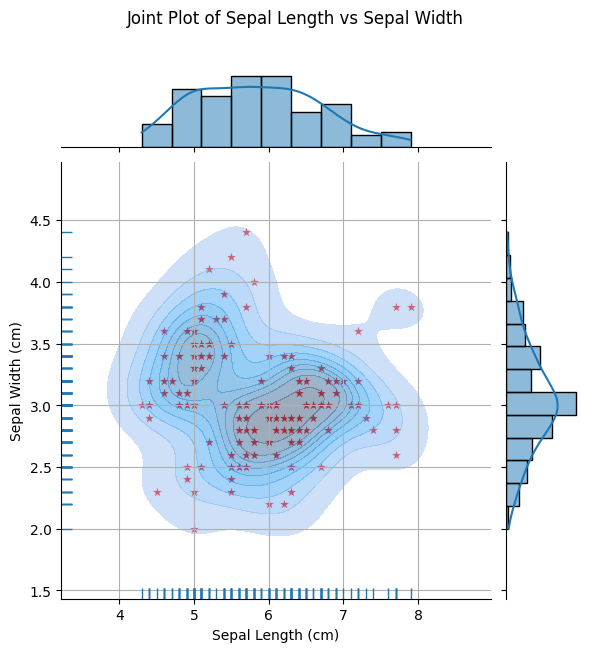

In [50]:
l=sns.jointplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    joint_kws=dict(marker='*', s=80, color='red'),
    marginal_kws=dict(kde=True),
)
l.plot_joint(sns.kdeplot, fill=True, alpha=0.5)
l.plot_joint(sns.rugplot)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
l.figure.suptitle('Joint Plot of Sepal Length vs Sepal Width', y=1.08)
plt.grid(True)

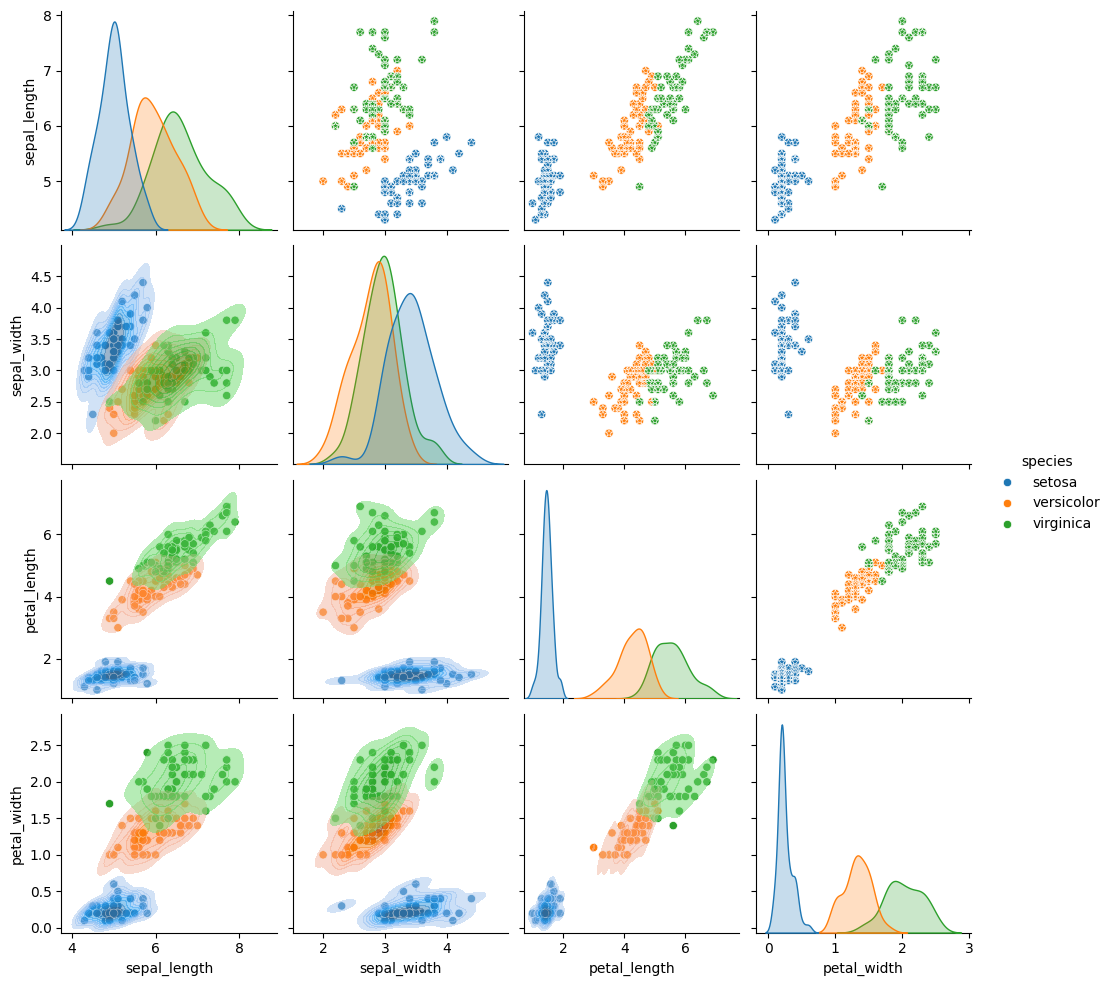

In [14]:
I= sns.pairplot(iris, hue='species', diag_kind='kde')
I.map_upper(sns.scatterplot, marker='*', s=30)
I.map_lower(sns.kdeplot, fill=True, alpha=0.5)

In [2]:
shop = pd.read_excel('mart_train_sample.xlsx')
shop.head()

,Item_ID,Item_W,Item_Type,Item_MRP,Outlet_ID,Outlet_Year,Outlet_Size,Outlet_Location_Type,Sales,Tier
0,FDN27,9.437510,Snack Foods,195.313244,OUT046,1997,Small,Tier 1,897.085562,1
1,FDW35,9.033762,Fruits and Vegetables,36.371449,OUT035,2003,Small,Tier 2,1639.303513,2
2,FDS28,20.884849,Frozen Foods,70.318167,OUT013,2008,Small,Tier 1,2664.773737,1
3,FDC09,19.976300,Snack Foods,121.723264,OUT018,2009,Medium,Tier 3,440.859593,3
4,FDX04,10.824812,Snack Foods,264.673302,OUT035,2004,Small,Tier 1,29.807098,1


<Axes: xlabel='Item_MRP', ylabel='Sales'>

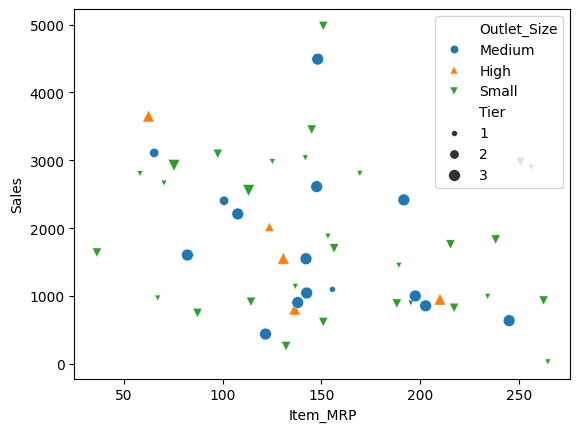

In [15]:

sns.scatterplot(
    data=shop,
    x='Item_MRP',
    y='Sales',
    hue='Outlet_Size',
    size='Tier',
    style='Outlet_Size',
    markers={'High':'^', 'Small':'v', 'Medium':'o'}
)


C:\Users\Mazhar Iqbal\AppData\Local\Temp\ipykernel_13976\1436798415.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data= shop, x='Outlet_Year', y='Sales', ci= 90, estimator= sum, hue='Outlet_Size', markers=True, style='Outlet_Size')


<Axes: xlabel='Outlet_Year', ylabel='Sales'>

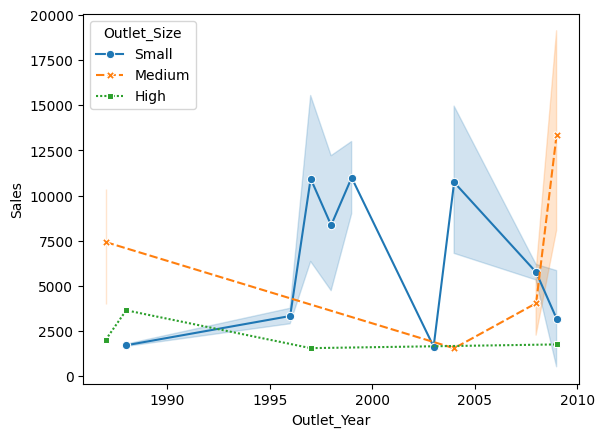

In [20]:
sns.lineplot(data= shop, x='Outlet_Year', y='Sales', ci= 90, estimator= sum, hue='Outlet_Size', markers=True, style='Outlet_Size')

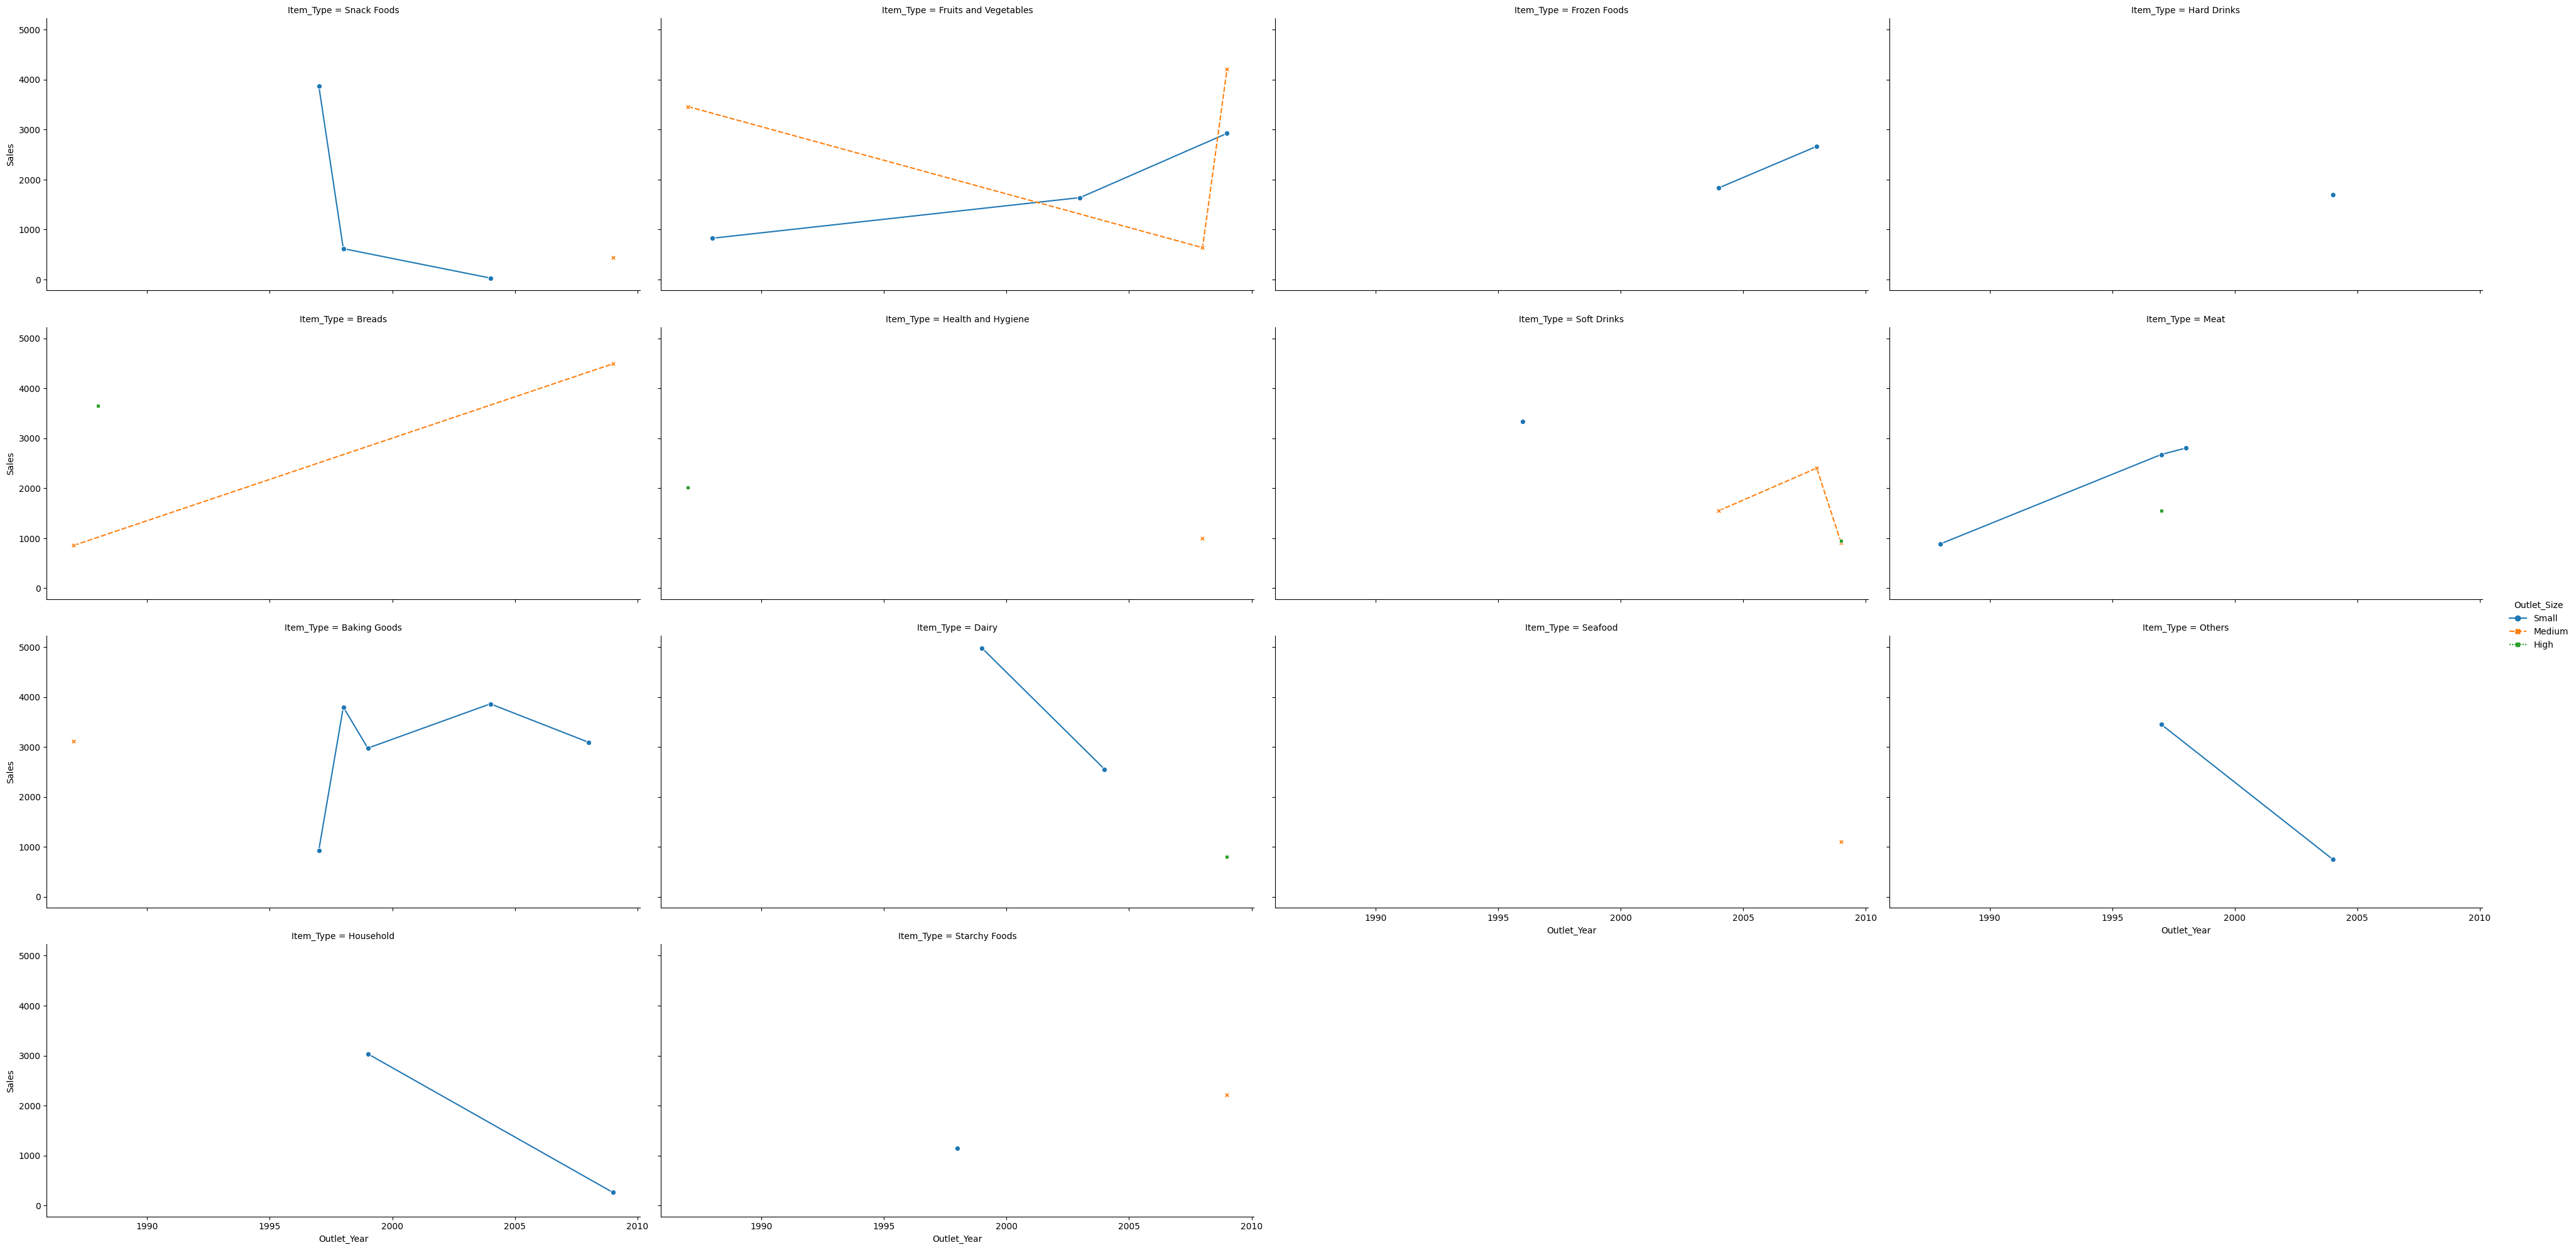

In [ ]:
sns.relplot(
    data=shop,x= 'Outlet_Year', y='Sales', hue='Outlet_Size', kind='line', errorbar=None , estimator= sum, markers=True, style='Outlet_Size', height=5, aspect=2
    ,col='Item_Type'
    , col_wrap= 4
   )

<Axes: xlabel='Item_MRP', ylabel='Sales'>

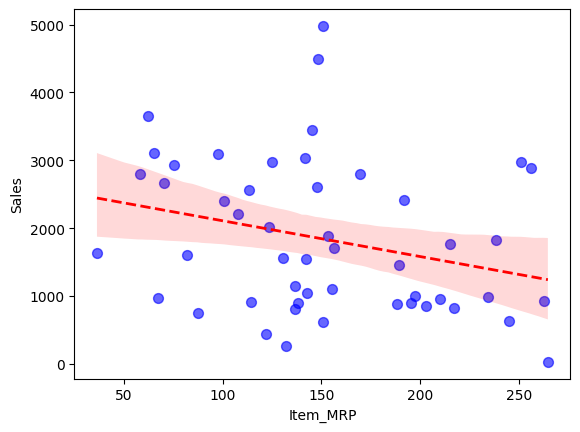

In [13]:
sns.regplot(
    data= shop,x= 'Item_MRP', y='Sales', line_kws={'color':'red','lw':2,'ls':'--'}, scatter_kws={'s':50,'color':'blue','alpha':0.6})
#line_kws=dict(color='red',linewidth= 2,linestyle ='--')

In [6]:
# ...existing code...
shoppiv = shop.pivot_table(index='Outlet_Year', columns='Outlet_Size', values='Sales')
shoppiv = shoppiv.fillna(0)
# ...existing code...
shoppiv

Outlet_Size,High,Medium,Small
Outlet_Year,,,
1987,2017.995778,1856.803961,0.000000
1988,3651.266895,0.000000,857.786220
1996,0.000000,0.000000,1667.377374
1997,1556.877108,0.000000,1822.922785
1998,0.000000,0.000000,1672.015000
1999,0.000000,0.000000,3663.856641
2003,0.000000,0.000000,1639.303513
2004,0.000000,1549.733966,1533.338409
2008,0.000000,1347.352085,2880.060279


<Axes: xlabel='Outlet_Size', ylabel='Outlet_Year'>

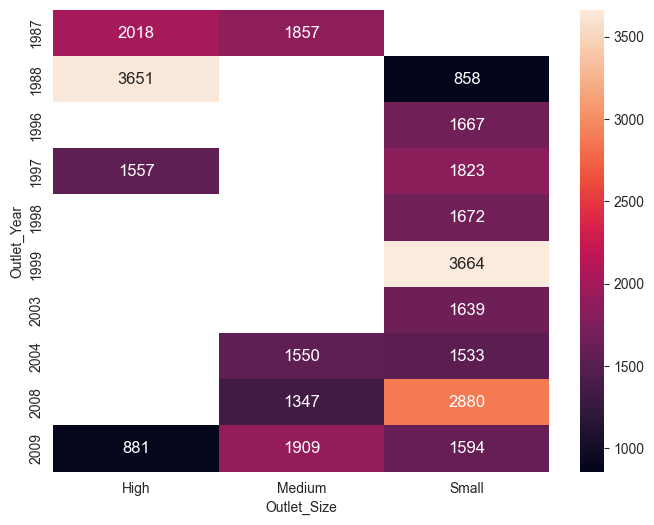

In [24]:
sns.set_style('white')
plt.figure(figsize=(8,6))
sns.heatmap(shoppiv, annot= True, fmt= '.0f', annot_kws={'size':12})

<Axes: >

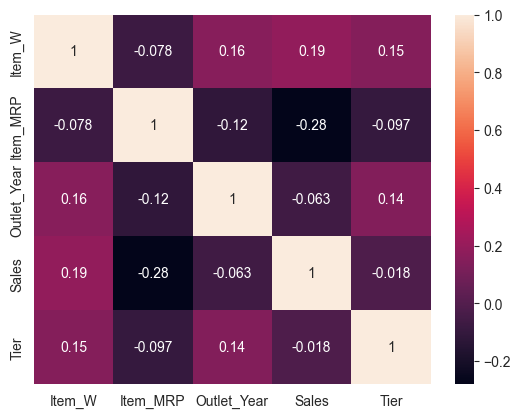

In [29]:
sns.heatmap(shop.corr(numeric_only=True), annot=True)

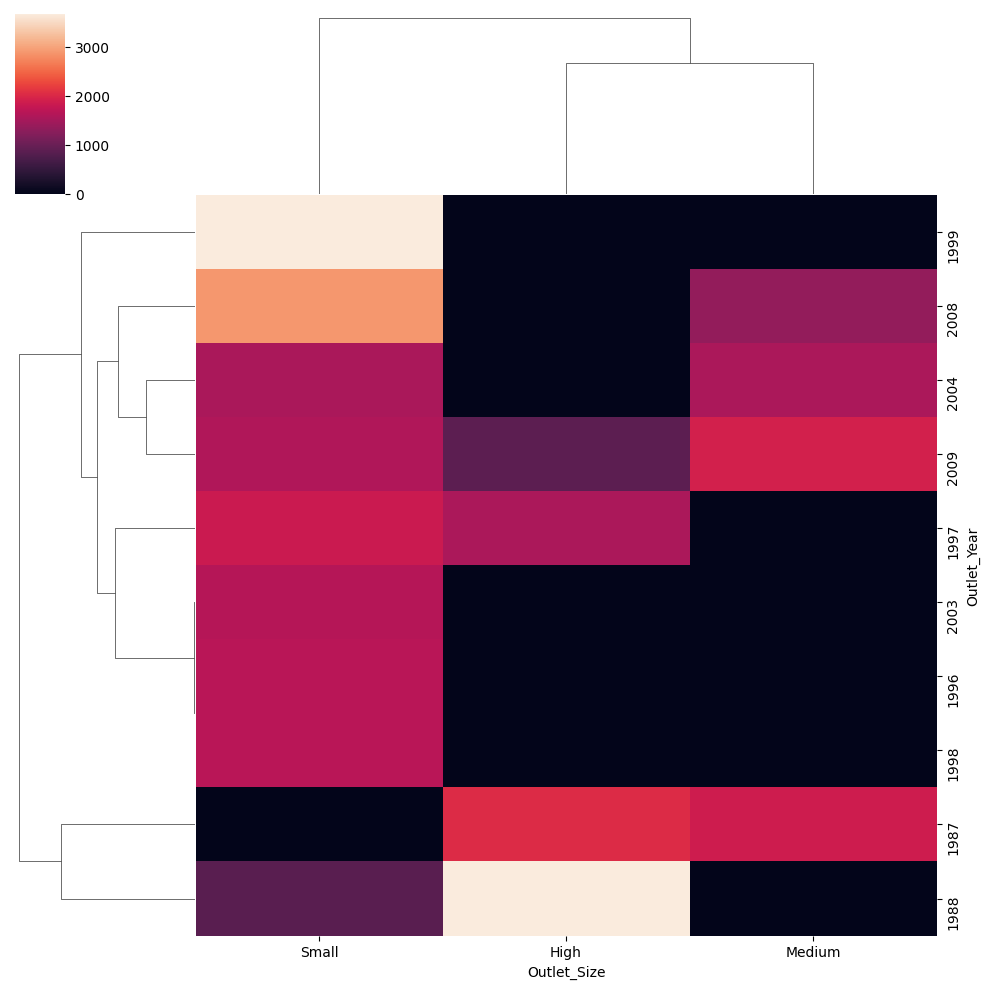

In [7]:
sns.clustermap(shoppiv)

In [3]:
mart.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Mandalay,Member,Female,Food_and_beverages,54.84,3,8.226,172.746,2/20/2019,13:27:00,Credit card,164.52,4.761905,8.226,5.9
1,351-62-0822,B,Mandalay,Member,Female,Fashion_accessories,14.48,4,2.896,60.816,2019-06-02 00:00:00,18:07:00,Ewallet,57.92,4.761905,2.896,4.5
2,529-56-3974,B,Mandalay,Member,Male,Electronic_accessories,25.51,4,5.102,107.142,2019-09-03 00:00:00,17:03:00,Cash,102.04,4.761905,5.102,6.8
3,299-46-1805,B,Mandalay,Member,Female,Sports_and_travel,93.72,6,28.116,590.436,1/15/2019,16:19:00,Cash,562.32,4.761905,28.116,4.5
4,319-50-3348,B,Mandalay,Normal,Female,Home_and_lifestyle,40.30,2,4.030,84.630,2019-11-03 00:00:00,15:30:00,Ewallet,80.60,4.761905,4.030,4.4


In [5]:
mart.City.unique()

array(['Mandalay', 'Naypyitaw', 'Yangon'], dtype=object)

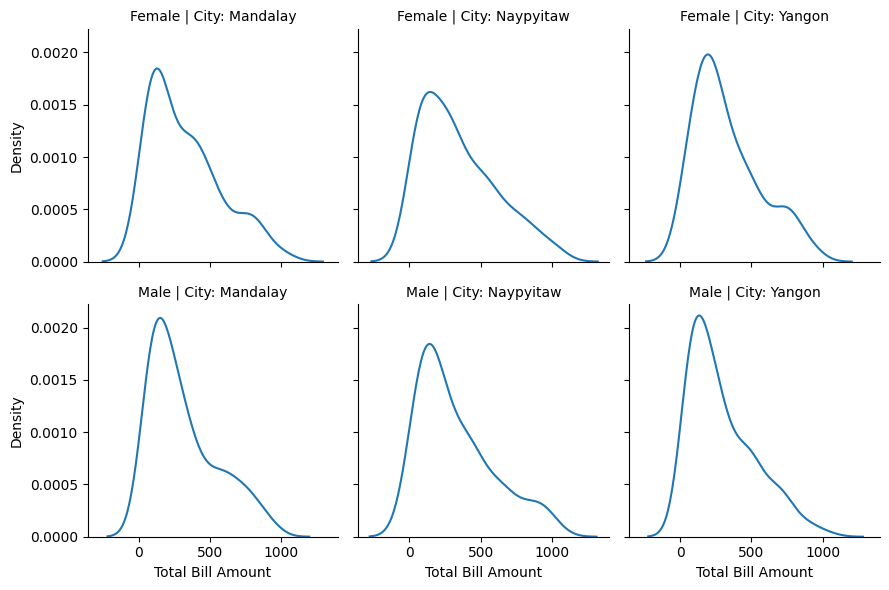

In [6]:
a = sns.FacetGrid(data= mart, col= 'City',row='Gender')
a.map_dataframe(sns.kdeplot, x= 'Total')
a.set_axis_labels('Total Bill Amount', 'Density')
a.set_titles(col_template= 'City: {col_name}', row_template= '{row_name}')